# 6주차: 지도학습 (1) - 회귀 분석 + 동적 프로그래밍
**건국대학교 AI활용실습 | 2026학년도 1학기**

---
### 📋 학습 목표
1. 선형 회귀(Linear Regression)를 직접 구현하고 scikit-learn과 비교
2. 경사하강법(Gradient Descent) 동작 원리를 시각화로 이해
3. Ridge / Lasso 정규화 비교
4. BFS, DFS, Backtracking 알고리즘 구현
5. 탐색 알고리즘이 딥러닝·AI에 어떻게 쓰이는지 이해

In [6]:
import matplotlib as mpl
import os
import shutil
# 캐시 폴더 찾아서 삭제하기
cache_dir = mpl.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("캐시가 삭제되었습니다.")

캐시가 삭제되었습니다.


In [8]:
# 1. 리눅스(우분투) 시스템에 나눔고딕 폰트 설치 (시간이 조금 걸릴 수 있습니다)
!apt-get update -y
!apt-get install -y fonts-nanum

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import os
import matplotlib as mpl

# 캐시 폴더가 없어져서 날 수 있는 에러 방지용
os.makedirs(mpl.get_cachedir(), exist_ok=True)

# 2. 설치한 나눔고딕 폰트 경로를 직접 지정해서 강제 적용
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

print("\n✅ 리눅스 환경에 나눔고딕 설치 및 폰트 설정 완료!")


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable/main amd64 Packages [357 B]       
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Hit:6 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]           
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [10.1 MB]   
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease   
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,857 kB]
Get:13 https://ppa.launchpadcon

In [2]:
# ─── 필요한 라이브러리 임포트 ───────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import deque

# scikit-learn
from sklearn.datasets import load_diabetes, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# 한글 폰트 설정 (Colab 환경)
plt.rcParams['axes.unicode_minus'] = False
try:
    plt.rcParams['font.family'] = 'NanumGothic'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


---
## 실습 1: 선형 회귀 (Linear Regression)

### 1-1. 데이터 준비

**당뇨병 데이터셋**을 사용합니다. 10가지 생체지표로 1년 후 당뇨 진행 정도를 예측합니다.

In [34]:
# 데이터 로드
diabetes = load_diabetes()
X = diabetes.data        # (442, 10) - 10개 특성
y = diabetes.target      # (442,)    - 연속값 (당뇨 진행 지수)

print('데이터 형태:', X.shape)
print('특성 이름:', diabetes.feature_names)
print('타깃 범위: {:.1f} ~ {:.1f}'.format(y.min(), y.max()))

# 훈련/테스트 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 스케일링 (훈련 기준으로 변환)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('\n훈련 샘플:', X_train.shape[0], '/ 테스트 샘플:', X_test.shape[0])

데이터 형태: (442, 10)
특성 이름: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
타깃 범위: 25.0 ~ 346.0

훈련 샘플: 353 / 테스트 샘플: 89


### 1-2. 선형 회귀 직접 구현 (Normal Equation)

$$\hat{\theta} = (X^T X)^{-1} X^T y$$

In [4]:
class LinearRegressionManual:
    """선형 회귀 직접 구현 (Normal Equation)"""
    
    def fit(self, X, y):
        # 편향(bias)을 위한 1열 추가
        n = X.shape[0]
        X_b = np.hstack([np.ones((n, 1)), X])  # (n, p+1)
        # 정규방정식: theta = (X^T X)^-1 X^T y
        self.theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
        return self
    
    def predict(self, X):
        n = X.shape[0]
        X_b = np.hstack([np.ones((n, 1)), X])
        return X_b @ self.theta

# 훈련 및 예측
lr_manual = LinearRegressionManual()
lr_manual.fit(X_train_scaled, y_train)
y_pred_manual = lr_manual.predict(X_test_scaled)

mse_manual = mean_squared_error(y_test, y_pred_manual)
r2_manual  = r2_score(y_test, y_pred_manual)
print('=== 직접 구현 결과 ===')
print(f'MSE:  {mse_manual:.2f}')
print(f'RMSE: {np.sqrt(mse_manual):.2f}')
print(f'R²:   {r2_manual:.4f}')

=== 직접 구현 결과 ===
MSE:  2900.19
RMSE: 53.85
R²:   0.4526


=== scikit-learn 결과 ===
MSE:  2900.19
RMSE: 53.85
R²:   0.4526


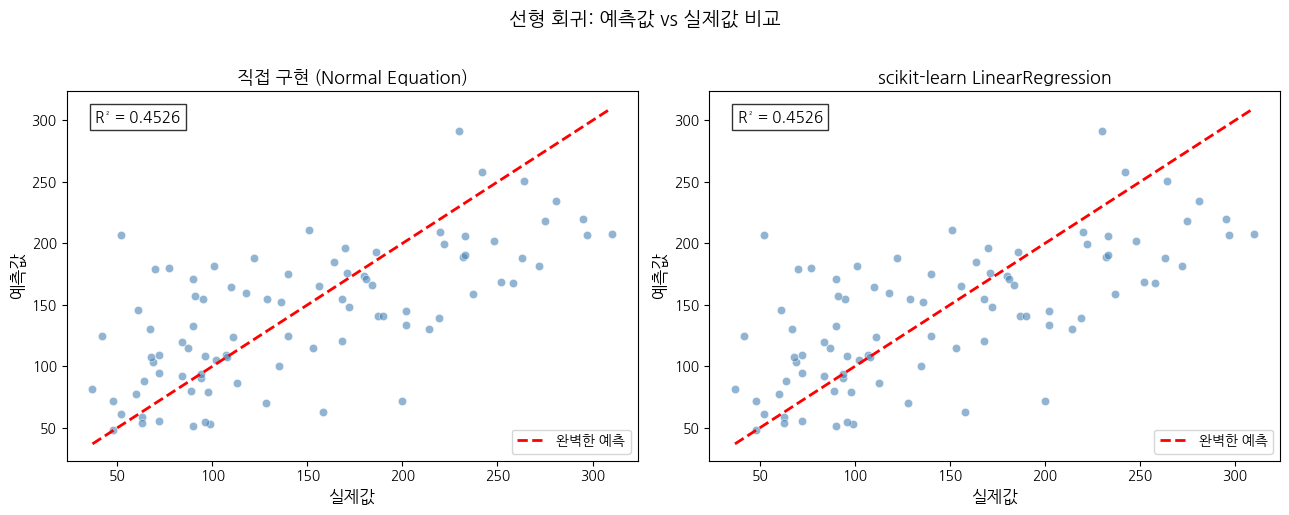

In [5]:
# scikit-learn과 비교
lr_sklearn = LinearRegression()
lr_sklearn.fit(X_train_scaled, y_train)
y_pred_sklearn = lr_sklearn.predict(X_test_scaled)

mse_sk = mean_squared_error(y_test, y_pred_sklearn)
r2_sk  = r2_score(y_test, y_pred_sklearn)
print('=== scikit-learn 결과 ===')
print(f'MSE:  {mse_sk:.2f}')
print(f'RMSE: {np.sqrt(mse_sk):.2f}')
print(f'R²:   {r2_sk:.4f}')

# 시각화: 예측값 vs 실제값
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, preds, title in zip(axes,
    [y_pred_manual, y_pred_sklearn],
    ['직접 구현 (Normal Equation)', 'scikit-learn LinearRegression']):
    ax.scatter(y_test, preds, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)
    lo = min(y_test.min(), preds.min())
    hi = max(y_test.max(), preds.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=2, label='완벽한 예측')
    ax.set_xlabel('실제값', fontsize=12)
    ax.set_ylabel('예측값', fontsize=12)
    ax.set_title(title, fontsize=13)
    r2 = r2_score(y_test, preds)
    ax.text(0.05, 0.95, f'R² = {r2:.4f}', transform=ax.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.8))
    ax.legend()
plt.suptitle('선형 회귀: 예측값 vs 실제값 비교', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---
## 실습 2: 경사하강법 (Gradient Descent) 시각화

$$\theta_j := \theta_j - \alpha \cdot \frac{\partial J}{\partial \theta_j}$$

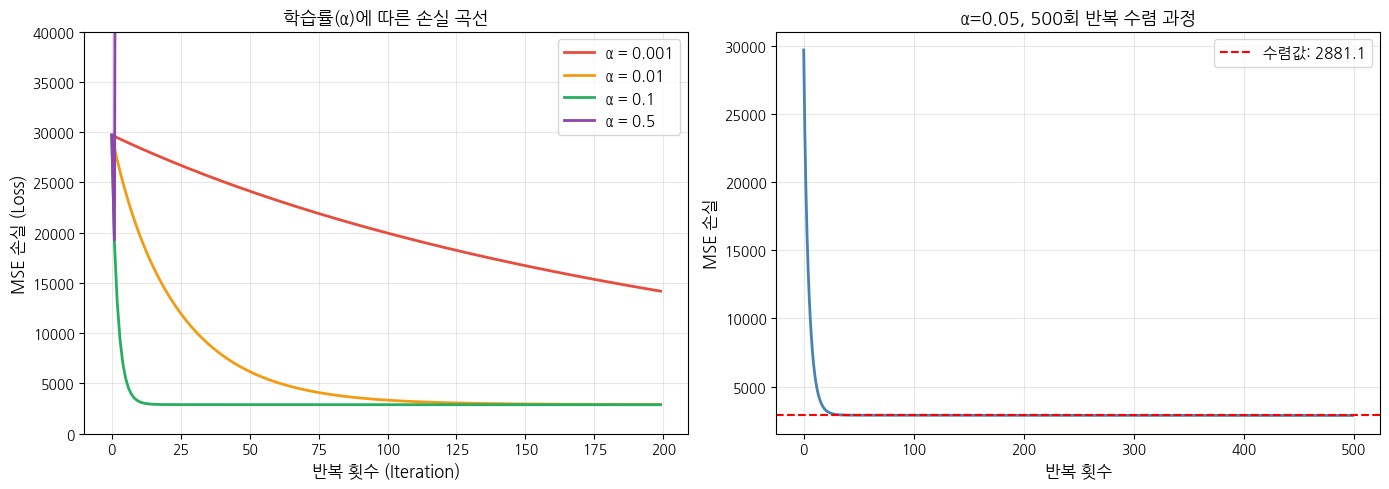


최적화된 θ (처음 5개): [153.74   1.9  -11.46  26.11  16.67]


In [6]:
def gradient_descent(X, y, alpha=0.01, n_iter=1000):
    """
    배치 경사하강법 (Batch Gradient Descent)
    X: 특성 행렬, y: 타깃, alpha: 학습률, n_iter: 반복 횟수
    """
    m, n = X.shape
    # 편향 추가
    X_b = np.hstack([np.ones((m, 1)), X])
    theta = np.zeros(n + 1)  # 파라미터 초기화
    loss_history = []
    
    for i in range(n_iter):
        # 예측
        y_pred = X_b @ theta
        # 오차
        error = y_pred - y
        # MSE 손실
        loss = (1 / m) * np.sum(error ** 2)
        loss_history.append(loss)
        # 기울기(gradient) 계산
        gradient = (2 / m) * X_b.T @ error
        # 파라미터 업데이트
        theta -= alpha * gradient
    
    return theta, loss_history


# 학습률별 비교
alphas = [0.001, 0.01, 0.1, 0.5]
colors = ['#e74c3c', '#f39c12', '#27ae60', '#8e44ad']
n_iter = 200

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 손실 곡선
for alpha, color in zip(alphas, colors):
    theta, losses = gradient_descent(X_train_scaled, y_train, alpha=alpha, n_iter=n_iter)
    axes[0].plot(losses, label=f'α = {alpha}', color=color, lw=2)

axes[0].set_xlabel('반복 횟수 (Iteration)', fontsize=12)
axes[0].set_ylabel('MSE 손실 (Loss)', fontsize=12)
axes[0].set_title('학습률(α)에 따른 손실 곡선', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].set_ylim(0, 40000)
axes[0].grid(True, alpha=0.3)

# 오른쪽: 최적 학습률로 수렴 과정
theta_best, losses_best = gradient_descent(X_train_scaled, y_train, alpha=0.05, n_iter=500)
axes[1].plot(losses_best, color='steelblue', lw=2)
axes[1].axhline(y=losses_best[-1], color='red', linestyle='--', lw=1.5,
                label=f'수렴값: {losses_best[-1]:.1f}')
axes[1].set_xlabel('반복 횟수', fontsize=12)
axes[1].set_ylabel('MSE 손실', fontsize=12)
axes[1].set_title('α=0.05, 500회 반복 수렴 과정', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'\n최적화된 θ (처음 5개): {theta_best[:5].round(2)}')

---
## 실습 3: Ridge & Lasso 정규화

| 방식 | 비용함수 | 효과 |
|------|---------|------|
| Ridge (L2) | MSE + λ·Σθ² | θ 축소 (완전히 0은 아님) |
| Lasso (L1) | MSE + λ·Σ\|θ\| | 일부 θ → 정확히 0 (특성 선택) |

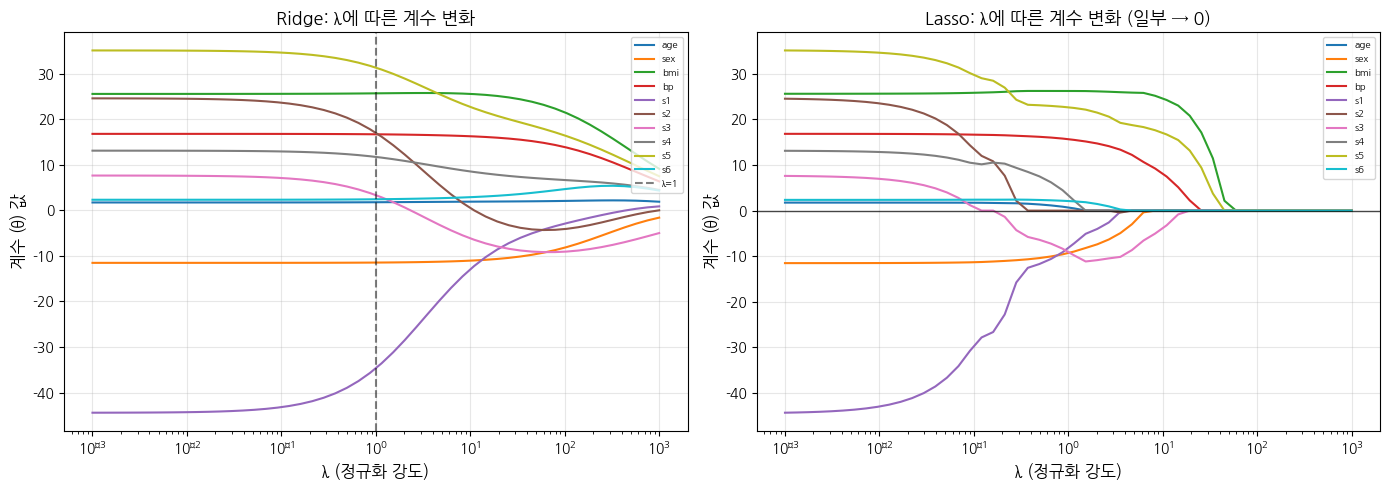

In [7]:
# λ 값별 계수 변화 비교
alphas_reg = np.logspace(-3, 3, 50)  # 0.001 ~ 1000

ridge_coefs = []
lasso_coefs = []

for a in alphas_reg:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge.coef_)
    
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso.coef_)

ridge_coefs = np.array(ridge_coefs)
lasso_coefs = np.array(lasso_coefs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
feature_names = diabetes.feature_names

# Ridge 계수 경로
for i, name in enumerate(feature_names):
    axes[0].plot(alphas_reg, ridge_coefs[:, i], label=name, lw=1.5)
axes[0].set_xscale('log')
axes[0].set_xlabel('λ (정규화 강도)', fontsize=12)
axes[0].set_ylabel('계수 (θ) 값', fontsize=12)
axes[0].set_title('Ridge: λ에 따른 계수 변화', fontsize=13)
axes[0].axvline(x=1.0, color='black', linestyle='--', alpha=0.5, label='λ=1')
axes[0].legend(fontsize=7, loc='upper right')
axes[0].grid(True, alpha=0.3)

# Lasso 계수 경로 (일부 0으로 수렴)
for i, name in enumerate(feature_names):
    axes[1].plot(alphas_reg, lasso_coefs[:, i], label=name, lw=1.5)
axes[1].set_xscale('log')
axes[1].set_xlabel('λ (정규화 강도)', fontsize=12)
axes[1].set_ylabel('계수 (θ) 값', fontsize=12)
axes[1].set_title('Lasso: λ에 따른 계수 변화 (일부 → 0)', fontsize=13)
axes[1].axhline(y=0, color='black', lw=1, alpha=0.7)
axes[1].legend(fontsize=7, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# 최적 λ 비교 (R² 성능)
print('{:<15} {:>8} {:>8} {:>12}'.format('모델', 'MSE', 'RMSE', 'R²'))
print('-' * 45)

models = [
    ('선형 회귀',  LinearRegression()),
    ('Ridge(λ=1)', Ridge(alpha=1.0)),
    ('Ridge(λ=10)',Ridge(alpha=10.0)),
    ('Lasso(λ=0.1)',Lasso(alpha=0.1, max_iter=10000)),
    ('Lasso(λ=1)', Lasso(alpha=1.0, max_iter=10000)),
]

for name, model in models:
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    mse  = mean_squared_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    print('{:<15} {:>8.1f} {:>8.2f} {:>12.4f}'.format(name, mse, np.sqrt(mse), r2))

# Lasso의 특성 선택 효과
lasso_best = Lasso(alpha=1.0, max_iter=10000)
lasso_best.fit(X_train_scaled, y_train)
print('\n=== Lasso(λ=1) 선택된 특성 (θ ≠ 0) ===')
selected = [(name, coef) for name, coef in zip(feature_names, lasso_best.coef_) if abs(coef) > 0.01]
for name, coef in sorted(selected, key=lambda x: abs(x[1]), reverse=True):
    print(f'  {name:5s}: {coef:+.3f}')

모델                   MSE     RMSE           R²
---------------------------------------------
선형 회귀             2900.2    53.85       0.4526
Ridge(λ=1)        2892.0    53.78       0.4541
Ridge(λ=10)       2875.8    53.63       0.4572
Lasso(λ=0.1)      2884.6    53.71       0.4555
Lasso(λ=1)        2824.6    53.15       0.4669

=== Lasso(λ=1) 선택된 특성 (θ ≠ 0) ===
  bmi  : +26.219
  s5   : +22.636
  bp   : +15.657
  sex  : -9.298
  s3   : -9.024
  s1   : -8.228
  s4   : +3.421
  s6   : +2.099
  age  : +0.687


---
## 실습 4: BFS (너비 우선 탐색)

**큐(Queue)**를 사용하여 그래프를 레벨별로 탐색합니다.

In [5]:
from collections import deque

def bfs(graph, start):
    """
    너비 우선 탐색 (BFS)
    graph: 인접 리스트 (dict)
    start: 시작 노드
    반환: 방문 순서
    """
    visited = set()
    queue   = deque([start])
    visited.add(start)
    order   = []
    
    while queue:
        node = queue.popleft()  # 큐 앞에서 꺼내기
        order.append(node)
        
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)  # 큐 뒤에 추가
    
    return order


def bfs_shortest_path(graph, start, goal):
    """BFS로 최단 경로 찾기"""
    if start == goal:
        return [start]
    
    visited = {start}
    queue   = deque([[start]])  # 경로 전체를 큐에 저장
    
    while queue:
        path = queue.popleft()
        node = path[-1]
        
        for neighbor in graph[node]:
            if neighbor not in visited:
                new_path = path + [neighbor]
                if neighbor == goal:
                    return new_path
                visited.add(neighbor)
                queue.append(new_path)
    
    return None  # 경로 없음


# 테스트 그래프
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F', 'G'],
    'D': ['B'],
    'E': ['B', 'H'],
    'F': ['C'],
    'G': ['C'],
    'H': ['E']
}

print('BFS 방문 순서 (A부터):', bfs(graph, 'A'))
print('최단 경로 A → H:', bfs_shortest_path(graph, 'A', 'H'))

BFS 방문 순서 (A부터): ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
최단 경로 A → H: ['A', 'B', 'E', 'H']


미로 최단 경로 길이: 9
경로: [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (3, 2), (3, 3), (3, 4), (4, 4)]


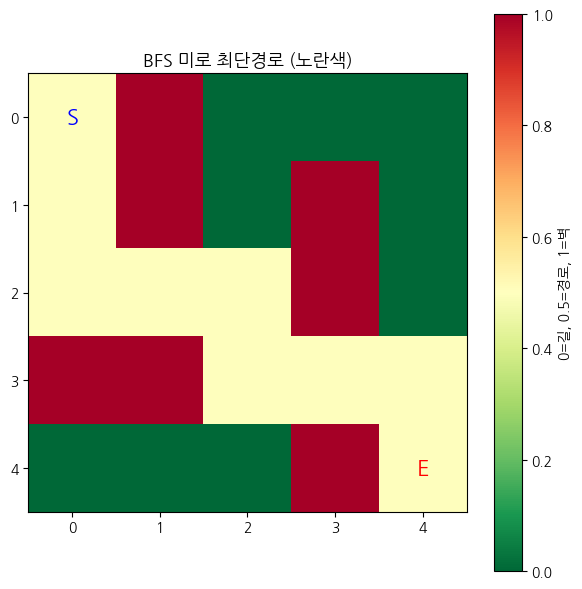

In [12]:
# 미로(Grid) BFS 최단경로
def bfs_maze(maze, start, end):
    """
    2D 미로 BFS 탐색
    0 = 이동 가능, 1 = 벽
    """
    rows, cols = len(maze), len(maze[0])
    directions = [(0,1),(0,-1),(1,0),(-1,0)]  # 상하좌우
    
    visited = {start}
    queue   = deque([(start, [start])])
    
    while queue:
        (r, c), path = queue.popleft()
        
        if (r, c) == end:
            return path
        
        for dr, dc in directions:
            nr, nc = r+dr, c+dc
            if 0<=nr<rows and 0<=nc<cols and maze[nr][nc]==0 and (nr,nc) not in visited:
                visited.add((nr, nc))
                queue.append(((nr, nc), path + [(nr, nc)]))
    
    return None


# 미로 정의 (0: 길, 1: 벽)
maze = [
    [0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0],
    [1, 1, 0, 0, 0],
    [0, 0, 0, 1, 0]
]

start, end = (0, 0), (4, 4)
path = bfs_maze(maze, start, end)
print('미로 최단 경로 길이:', len(path) if path else '없음')
print('경로:', path)

# 시각화
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
maze_arr = np.array(maze, dtype=float)

# 경로 표시
if path:
    for r, c in path:
        maze_arr[r][c] = 0.5

ax.imshow(maze_arr, cmap='RdYlGn_r', vmin=0, vmax=1)
ax.text(start[1], start[0], 'S', ha='center', va='center', fontsize=16, fontweight='bold', color='blue')
ax.text(end[1],   end[0],   'E', ha='center', va='center', fontsize=16, fontweight='bold', color='red')
ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_title('BFS 미로 최단경로 (노란색)', fontsize=13)
plt.colorbar(ax.images[0], ax=ax, label='0=길, 0.5=경로, 1=벽')
plt.tight_layout()
plt.show()

---
## 실습 5: DFS (깊이 우선 탐색)

**스택(재귀 또는 명시적 스택)**으로 한 방향을 끝까지 탐색합니다.

In [11]:
# 재귀 방식 DFS
def dfs_recursive(graph, node, visited=None, order=None):
    """
    깊이 우선 탐색 (재귀 방식)
    재귀 구조 = 신경망의 순전파(Forward Pass)와 동일한 구조!
    """
    if visited is None:
        visited = set()
        order   = []
    
    visited.add(node)
    order.append(node)
    
    for neighbor in graph[node]:
        if neighbor not in visited:
            dfs_recursive(graph, neighbor, visited, order)
    
    return order


# 반복(Iterative) 방식 DFS (스택 사용)
def dfs_iterative(graph, start):
    """깊이 우선 탐색 (명시적 스택 사용)"""
    visited = set()
    stack   = [start]
    order   = []
    
    while stack:
        node = stack.pop()  # 스택 최상단에서 꺼내기
        
        if node not in visited:
            visited.add(node)
            order.append(node)
            # 역순으로 추가 (원래 순서 유지)
            for neighbor in reversed(graph[node]):
                if neighbor not in visited:
                    stack.append(neighbor)
    
    return order


# 테스트
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F', 'G'],
    'D': ['B'],
    'E': ['B', 'H'],
    'F': ['C'],
    'G': ['C'],
    'H': ['E']
}

print('BFS 방문 순서:', bfs(graph, 'A'))
print('DFS 방문 순서 (재귀):', dfs_recursive(graph, 'A'))
print('DFS 방문 순서 (반복):', dfs_iterative(graph, 'A'))
print()
print('💡 BFS: 레벨별(너비 우선) | DFS: 한 방향 끝까지(깊이 우선)')

BFS 방문 순서: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']
DFS 방문 순서 (재귀): ['A', 'B', 'D', 'E', 'H', 'C', 'F', 'G']
DFS 방문 순서 (반복): ['A', 'B', 'D', 'E', 'H', 'C', 'F', 'G']

💡 BFS: 레벨별(너비 우선) | DFS: 한 방향 끝까지(깊이 우선)


In [12]:
# ─── DFS와 신경망 순전파의 연결 ────────────────────────────────
print('=== DFS 구조와 신경망 Forward Pass 비교 ===')
print()

# 간단한 신경망 수동 계산 (DFS처럼 레이어를 순서대로 통과)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

# 간단한 2층 신경망 forward pass
np.random.seed(42)
x_input = np.array([1.0, 2.0, 3.0])  # 입력

# 가중치 초기화
W1 = np.random.randn(4, 3) * 0.1  # Layer 1: 3→4
b1 = np.zeros(4)
W2 = np.random.randn(2, 4) * 0.1  # Layer 2: 4→2
b2 = np.zeros(2)

# 순전파 (DFS처럼 층을 순서대로 통과)
print('입력층 x:', x_input)

z1 = W1 @ x_input + b1   # 선형 변환
a1 = relu(z1)             # 활성화 함수 (ReLU)
print('은닉층 활성화값 a1:', np.round(a1, 4))

z2 = W2 @ a1 + b2        # 다음 레이어
a2 = sigmoid(z2)          # 출력 (sigmoid)
print('출력층 a2 (예측 확률):', np.round(a2, 4))
print()
print('✅ 신경망 순전파 = DFS와 동일한 재귀적 합성 함수 구조!')
print('   f₃(f₂(f₁(x))) ← 이것이 딥러닝의 기본 계산 구조')

=== DFS 구조와 신경망 Forward Pass 비교 ===

입력층 x: [1. 2. 3.]
은닉층 활성화값 a1: [0.2163 0.0352 0.1706 0.    ]
출력층 a2 (예측 확률): [0.4923 0.4909]

✅ 신경망 순전파 = DFS와 동일한 재귀적 합성 함수 구조!
   f₃(f₂(f₁(x))) ← 이것이 딥러닝의 기본 계산 구조


---
## 실습 6: Backtracking

**가지치기(Pruning)**를 통해 불필요한 탐색을 건너뜁니다.  
딥러닝의 **역전파(Backpropagation)**와 **하이퍼파라미터 탐색**의 기초입니다.

후보: [2, 3, 6, 7], 목표 합: 7
가능한 조합: [[2, 2, 3], [7]]

6-Queen 해의 수: 4개
첫 번째 해: [1, 3, 5, 0, 2, 4]


/tmp/ipykernel_19418/3920016983.py:91: UserWarning: Glyph 9819 (\N{BLACK CHESS QUEEN}) missing from font(s) NanumGothic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9819 (\N{BLACK CHESS QUEEN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


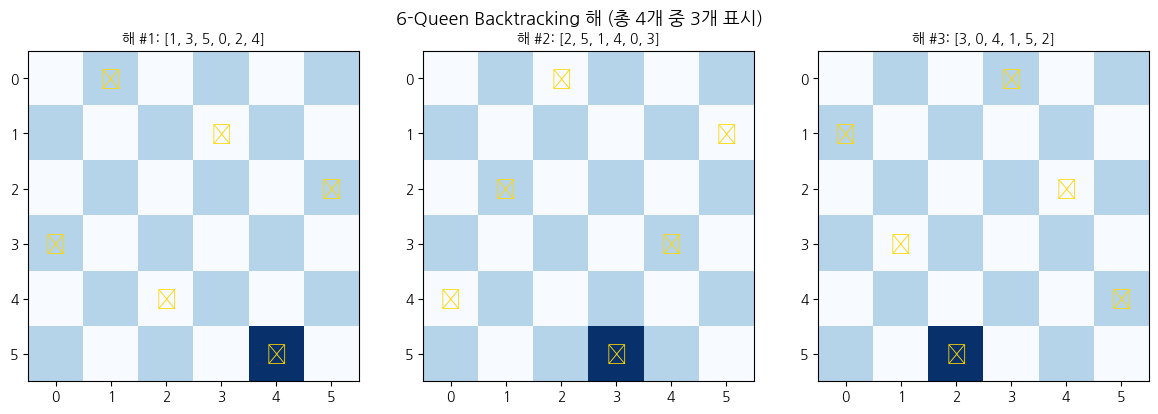

In [13]:
# ─── 예제 1: 조합 합 (Combination Sum) ────────────────────────
def combination_sum(candidates, target):
    """
    주어진 후보 숫자들로 합이 target이 되는 모든 조합 찾기
    가지치기: target < 0이면 즉시 종료
    """
    result = []
    candidates.sort()  # 정렬 (가지치기 효율 증가)
    
    def backtrack(start, path, remaining):
        if remaining == 0:
            result.append(list(path))  # 정답 발견
            return
        
        for i in range(start, len(candidates)):
            if candidates[i] > remaining:
                break  # ✂️ 가지치기: 이후 값은 더 크므로 불필요
            
            path.append(candidates[i])
            backtrack(i, path, remaining - candidates[i])
            path.pop()  # ↩️ 백트래킹: 이전 상태로 복원
    
    backtrack(0, [], target)
    return result

candidates = [2, 3, 6, 7]
target = 7
result = combination_sum(candidates, target)
print(f'후보: {candidates}, 목표 합: {target}')
print(f'가능한 조합: {result}')
print()


# ─── 예제 2: N-Queen 문제 ──────────────────────────────────────
def solve_n_queens(n):
    """
    N-Queen 문제: n×n 체스판에 퀸 n개를 서로 공격 못하도록 배치
    딥러닝 연결: 각 레이어에서 최적의 파라미터 값 탐색과 유사
    """
    solutions = []
    board = [-1] * n  # board[i] = i번째 행의 퀸 열 위치
    
    def is_valid(row, col):
        """현재 위치에 퀸 배치 가능 여부"""
        for prev_row in range(row):
            prev_col = board[prev_row]
            if prev_col == col:                        # 같은 열
                return False
            if abs(prev_col - col) == abs(prev_row - row):  # 대각선
                return False
        return True
    
    def backtrack(row):
        if row == n:
            solutions.append(list(board))  # 완성!
            return
        
        for col in range(n):
            if is_valid(row, col):
                board[row] = col
                backtrack(row + 1)  # 다음 행으로
                board[row] = -1     # ↩️ 백트래킹
    
    backtrack(0)
    return solutions

n = 6
solutions = solve_n_queens(n)
print(f'{n}-Queen 해의 수: {len(solutions)}개')
print(f'첫 번째 해: {solutions[0]}')

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for idx, ax in enumerate(axes):
    sol = solutions[idx]
    board_vis = np.zeros((n, n))
    for row, col in enumerate(sol):
        # 체커보드 패턴
        for r in range(n):
            for c in range(n):
                board_vis[r][c] = (r + c) % 2 * 0.3
        board_vis[row][col] = 1.0
    ax.imshow(board_vis, cmap='Blues', vmin=0, vmax=1)
    for row, col in enumerate(sol):
        ax.text(col, row, '♛', ha='center', va='center', fontsize=18, color='gold')
    ax.set_title(f'해 #{idx+1}: {sol}', fontsize=10)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))

plt.suptitle(f'{n}-Queen Backtracking 해 (총 {len(solutions)}개 중 3개 표시)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 실습 7: 탐색 알고리즘 → 딥러닝 연결

### 역전파(Backpropagation)는 DFS + Backtracking!

$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial a_2} \cdot \frac{\partial a_2}{\partial z_2} \cdot \frac{\partial z_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial W_1}$$

=== 역전파 = 출력층에서 입력층 방향으로 오차 역전파 ===



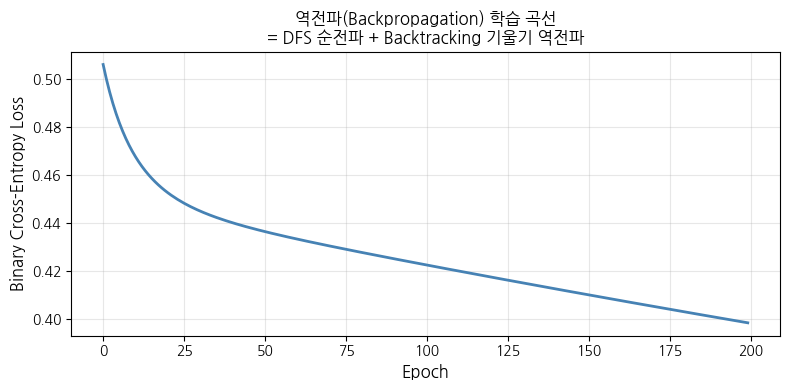

최종 손실: 0.3983
최종 가중치 W: [[0.456 0.097]]

✅ 핵심 연결:
  순전파  → DFS:         입력에서 출력으로 재귀적 계산
  역전파  → Backtracking: 출력에서 입력으로 기울기 역전파
  최적화  → 경사하강법:  학습률(α)로 파라미터 업데이트


In [14]:
# ─── 역전파 수동 구현: DFS + Backtracking 원리 시연 ────────────
print('=== 역전파 = 출력층에서 입력층 방향으로 오차 역전파 ===')
print()

# 간단한 1층 신경망 역전파
np.random.seed(0)

# 데이터
X_demo = np.array([[1, 2], [3, 4], [5, 6]], dtype=float)
y_demo = np.array([0, 1, 1], dtype=float)  # 이진 분류

# 가중치
W = np.random.randn(1, 2) * 0.1
b = 0.0

lr = 0.01
losses = []

for epoch in range(200):
    # ─ Forward Pass (DFS: 입력 → 출력) ─
    z = X_demo @ W.T + b      # 선형 결합 (n×1)
    a = sigmoid(z.flatten())  # sigmoid 활성화
    
    # 이진 교차엔트로피 손실
    eps = 1e-8
    loss = -np.mean(y_demo * np.log(a + eps) + (1 - y_demo) * np.log(1 - a + eps))
    losses.append(loss)
    
    # ─ Backward Pass (Backtracking: 출력 → 입력) ─
    dL_da = -(y_demo / (a + eps) - (1 - y_demo) / (1 - a + eps)) / len(y_demo)
    da_dz = a * (1 - a)           # sigmoid 미분
    dL_dz = dL_da * da_dz         # 연쇄 법칙
    
    dL_dW = dL_dz @ X_demo        # 가중치 기울기
    dL_db = np.sum(dL_dz)         # 편향 기울기
    
    # ─ 파라미터 업데이트 (경사하강법) ─
    W -= lr * dL_dW
    b -= lr * dL_db

# 결과 시각화
plt.figure(figsize=(8, 4))
plt.plot(losses, color='steelblue', lw=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Binary Cross-Entropy Loss', fontsize=12)
plt.title('역전파(Backpropagation) 학습 곡선\n= DFS 순전파 + Backtracking 기울기 역전파', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'최종 손실: {losses[-1]:.4f}')
print(f'최종 가중치 W: {W.round(3)}')
print()
print('✅ 핵심 연결:')
print('  순전파  → DFS:         입력에서 출력으로 재귀적 계산')
print('  역전파  → Backtracking: 출력에서 입력으로 기울기 역전파')
print('  최적화  → 경사하강법:  학습률(α)로 파라미터 업데이트')

---
## 🏆 도전 문제 (심화)

1. **도전 1**: 미로 크기를 10×10으로 늘리고 벽을 랜덤하게 생성하여 BFS로 최단경로를 구하세요.
2. **도전 2**: 경사하강법에 **모멘텀(Momentum)** 을 추가하여 수렴 속도를 개선하세요.  
   `v = β·v + (1-β)·∇J`,  `θ = θ - α·v`
3. **도전 3**: Lasso 회귀에서 선택된 특성만 사용한 모델과 모든 특성을 사용한 모델을 R²로 비교하세요.

미로 최단 경로 길이: 19
경로: [(0, 0), (0, 1), (1, 1), (1, 2), (2, 2), (2, 3), (2, 4), (3, 4), (3, 5), (3, 6), (3, 7), (4, 7), (5, 7), (6, 7), (6, 8), (6, 9), (7, 9), (8, 9), (9, 9)]


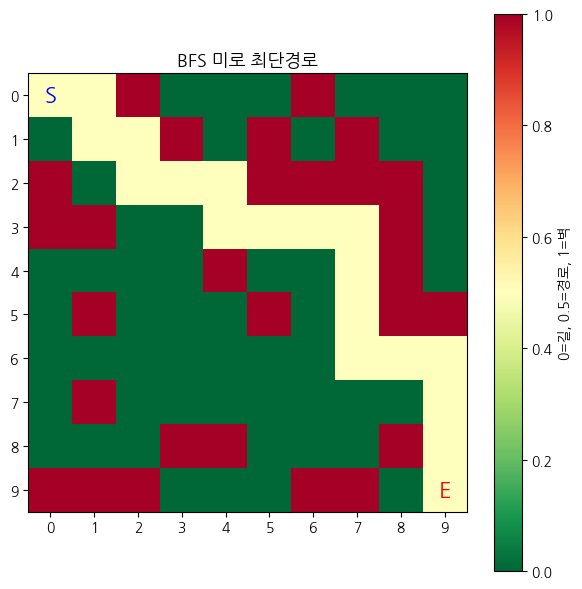

전체 특성 개수: 10개
Lasso가 선택한 핵심 특성 개수: 7개
선택된 특성들: ['sex' 'bmi' 'bp' 's1' 's3' 's5' 's6']

=== 선형 회귀 R² 스코어 비교 ===
모든 특성을 사용한 모델 (특성 10개) : 0.4526
핵심 특성만 사용한 모델 (특성 7개)  : 0.4661


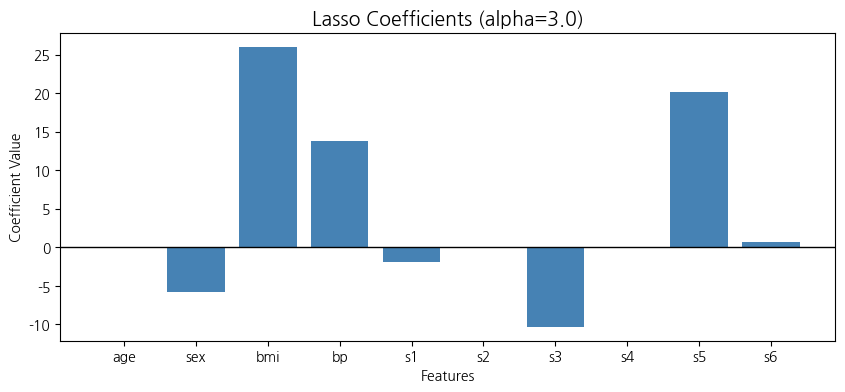

도전 문제 템플릿 준비 완료! 위 함수를 완성해보세요. 🚀


In [35]:
# 도전 문제를 여기에 풀어보세요!

import random
from collections import deque
import matplotlib.pyplot as plt
import numpy as np
def create_maze(size=10, wall_prob=0.3):
    # 무작위로 0(길) 또는 1(벽) 생성
    maze = [[1 if random.random() < wall_prob else 0 for _ in range(size)] for _ in range(size)]
    
    # 💡 필수 보정: 출발점과 도착점은 무조건 길(0)이 되도록 뚫어줍니다.
    maze[0][0] = 0
    maze[size-1][size-1] = 0
    
    return maze # 만들어진 미로를 반환
def bfs_maze(maze, start, end):
    """
    2D 미로 BFS 탐색
    0 = 이동 가능, 1 = 벽
    """
    rows, cols = len(maze), len(maze[0])
    directions = [(0,1),(0,-1),(1,0),(-1,0)]  # 상하좌우
    
    visited = {start}
    queue   = deque([(start, [start])])
    
    while queue:
        (r, c), path = queue.popleft()
        
        if (r, c) == end:
            return path
        
        for dr, dc in directions:
            nr, nc = r+dr, c+dc
            if 0<=nr<rows and 0<=nc<cols and maze[nr][nc]==0 and (nr,nc) not in visited:
                visited.add((nr, nc))
                queue.append(((nr, nc), path + [(nr, nc)]))
    
    return None
# 1. 미로 생성 및 변수 할당
maze = create_maze(size=10, wall_prob=0.3)
# 2. 경로 탐색
start, end = (0, 0), (9, 9)
path = bfs_maze(maze, start, end)
print('미로 최단 경로 길이:', len(path) if path else '없음 (길이 막혔습니다!)')
if path:
    print('경로:', path)
# 3. 시각화
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
maze_arr = np.array(maze, dtype=float)
# 경로 표시 (경로가 존재할 때만)
if path:
    for r, c in path:
        maze_arr[r][c] = 0.5
ax.imshow(maze_arr, cmap='RdYlGn_r', vmin=0, vmax=1)
ax.text(start[1], start[0], 'S', ha='center', va='center', fontsize=16, fontweight='bold', color='blue')
ax.text(end[1],   end[0],   'E', ha='center', va='center', fontsize=16, fontweight='bold', color='red')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
# 경로 유무에 따라 제목 다르게 표시
if path:
    ax.set_title('BFS 미로 최단경로', fontsize=13)
else:
    ax.set_title('길이 꽉 막힌 미로입니다 (경로 없음)', fontsize=13, color='red')
plt.colorbar(ax.images[0], ax=ax, label='0=길, 0.5=경로, 1=벽')
plt.tight_layout()
plt.show()


# 모멘텀 경사하강법
def gradient_descent_momentum(X, y, alpha=0.01, beta=0.9, n_iter=500):

    m, n = X.shape
    X_b   = np.hstack([np.ones((m, 1)), X])
    theta = np.zeros(n + 1)
    v     = np.zeros(n + 1)  # 속도(velocity) 초기화
    losses = []
    
    for _ in range(n_iter):
        y_pred   = X_b @ theta
        error    = y_pred - y
        loss     = (1/m) * np.sum(error**2)
        losses.append(loss)
        gradient = (2/m) * X_b.T @ error

        
        # TODO: 여기에 모멘텀 업데이트 규칙을 작성하세요
        # v = (beta * v) + ((1 - beta) * gradient)
        # theta = theta - (alpha * v)
        
    return theta, losses

from sklearn.linear_model import Lasso, LinearRegression
from sklearn.metrics import r2_score
import numpy as np
# 1. 모든 특성(10개)을 사용한 일반 다중 선형 회귀 모델
lr_all = LinearRegression()
lr_all.fit(X_train_scaled, y_train)
y_pred_all = lr_all.predict(X_test_scaled)
r2_all = r2_score(y_test, y_pred_all)
# 2. Lasso 회귀를 통한 특성 선택 (alpha로 규제 강도 조절)
# alpha가 클수록 더 많은 특성을 무시(0으로)합니다.
lasso_selector = Lasso(alpha=3.0, random_state=42) 
lasso_selector.fit(X_train_scaled, y_train)
# 가중치(coef_)가 0이 아닌 특성의 인덱스만 추출
selected_features_idx = np.where(lasso_selector.coef_ != 0)[0]
selected_features_names = np.array(diabetes.feature_names)[selected_features_idx]
print(f"전체 특성 개수: {X_train_scaled.shape[1]}개")
print(f"Lasso가 선택한 핵심 특성 개수: {len(selected_features_idx)}개")
print(f"선택된 특성들: {selected_features_names}")
# 3. Lasso로 선택된 특성 데이터만 따로 슬라이싱
X_train_selected = X_train_scaled[:, selected_features_idx]
X_test_selected = X_test_scaled[:, selected_features_idx]
# 4. 선택된 특성들만을 사용해서 새로운 선형 회귀 모델 학습
lr_selected = LinearRegression()
lr_selected.fit(X_train_selected, y_train)
y_pred_selected = lr_selected.predict(X_test_selected)
r2_selected = r2_score(y_test, y_pred_selected)
# 5. 결과 R² 스코어 비교
print("\n=== 선형 회귀 R² 스코어 비교 ===")
print(f"모든 특성을 사용한 모델 (특성 10개) : {r2_all:.4f}")
print(f"핵심 특성만 사용한 모델 (특성 {len(selected_features_idx)}개)  : {r2_selected:.4f}")
import matplotlib.pyplot as plt
# 6. 어떤 특성들이 제거되고 살아남았는지 시각화
plt.figure(figsize=(10, 4))
plt.bar(diabetes.feature_names, lasso_selector.coef_, color=['red' if c == 0 else 'steelblue' for c in lasso_selector.coef_])
plt.axhline(0, color='black', linewidth=1)
plt.title(f'Lasso Coefficients (alpha={lasso_selector.alpha})', fontsize=14)
plt.ylabel('Coefficient Value')
plt.xlabel('Features')
plt.show()   



print('도전 문제 템플릿 준비 완료! 위 함수를 완성해보세요. 🚀')

---
## 📝 6주차 핵심 요약

| 알고리즘 | 핵심 아이디어 | 딥러닝/AI 연결 |
|---------|-------------|---------------|
| 선형 회귀 | ŷ = Xθ, MSE 최소화 | 모든 회귀 모델의 기초 |
| 경사하강법 | θ := θ − α·∇J | 신경망 가중치 최적화 |
| Ridge/Lasso | L2/L1 정규화 | 과적합 방지, Dropout과 유사 |
| BFS | 큐, 레벨별 탐색 | GNN, 로봇 경로계획, A* |
| DFS | 스택/재귀, 깊이 탐색 | 순전파, 의사결정나무 |
| Backtracking | 가지치기, 역추적 | 역전파, AutoML, AlphaGo |

### 🔑 핵심 연결고리
```
BFS ──────────────→ Graph Neural Network, 로봇 경로계획
DFS(재귀) ─────────→ 신경망 순전파 (f₃(f₂(f₁(x))))
Backtracking ──────→ 역전파 (출력→입력 기울기 역전파)
경사하강법 ─────────→ 모든 딥러닝 옵티마이저 (Adam, SGD...)
```

> **다음 주 예고**: 지도학습 (2) - 분류 알고리즘 (Logistic Regression, Decision Tree)